---
## 1. Carga del archivo CSV (2%)

In [2]:
# Instalación de librerías (ejecutar solo si no están instaladas)
# !pip install mlxtend pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Cargar el archivo CSV
df = pd.read_csv('clave_I_asociacion.csv')

print('Archivo cargado exitosamente.')
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

Archivo cargado exitosamente.
Dimensiones del dataset: 679 filas x 7 columnas


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## 2. Primeras filas y estructura del dataset (2%)

In [3]:
# Primeras 10 filas
print('=== Primeras 10 filas ===')
display(df.head(10))

# Información general
print('\n=== Información general del dataset ===')
df.info()

# Frecuencia de ítems
print('\n=== Frecuencia de ítems ===')
print(df['item'].value_counts())

# Transacciones únicas
print(f'\nTransacciones únicas: {df["transaccion_id"].nunique()}')
print(f'Productos únicos:     {df["item"].nunique()}')
print(f'Categorías:           {df["categoria"].unique().tolist()}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Primeras 10 filas ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,I-T0001,I-C0019,2026-03-11,Bebidas,Agua,2,App
1,I-T0001,I-C0019,2026-03-11,Combos,Combo_infantil,2,App
2,I-T0001,I-C0019,2026-03-11,Postres,Tres_leches,1,App
3,I-T0002,I-C0071,2026-04-11,Postres,Helado,3,Tienda
4,I-T0002,I-C0071,2026-04-11,Platos,Pizza,1,Tienda
5,I-T0002,I-C0071,2026-04-11,Bebidas,Soda,1,Tienda
6,I-T0003,I-C0078,2026-02-02,Postres,Brownie,2,App
7,I-T0003,I-C0078,2026-02-02,Combos,Combo_infantil,1,App
8,I-T0003,I-C0078,2026-02-02,Entradas,Nachos,2,App
9,I-T0004,I-C0005,2026-02-28,Platos,Hamburguesa,1,Tienda



=== Información general del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  679 non-null    object
 1   cliente_id      679 non-null    object
 2   fecha           679 non-null    object
 3   categoria       679 non-null    object
 4   item            679 non-null    object
 5   cantidad        679 non-null    int64 
 6   canal           678 non-null    object
dtypes: int64(1), object(6)
memory usage: 37.3+ KB

=== Frecuencia de ítems ===
item
Soda               80
Pizza              55
Combo_infantil     52
Helado             52
Hamburguesa        49
Pasta              42
Cafe               40
Papas              36
Combo_pareja       33
Nachos             27
Agua               26
Jugo               23
Flan               23
Brownie            22
Combo_familiar     21
Combo_ejecutivo    21
Tres_leches        20


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
##Interpretación: El dataset tiene formato largo (una fila por ítem comprado). Las columnas más relevantes para el análisis son:

#transaccion_id: identificador único de cada compra (205 transacciones únicas).
#item: nombre del producto adquirido (20 productos distintos: Agua, Pizza, Brownie, Helado, Combo_infantil, Hamburguesa, etc.).
#categoria: categoría del producto (Bebidas, Combos, Postres, Platos, Entradas).
#canal: canal de venta (App o Tienda).

---
## 3. Verificación de valores nulos, duplicados y tipos de datos (3%)

In [4]:
# --- Valores nulos ---
print('=== Valores nulos por columna ===')
nulos = df.isnull().sum()
print(nulos)
print(f'\nTotal de valores nulos: {nulos.sum()}')

# --- Filas duplicadas ---
print('\n=== Filas duplicadas ===')
duplicados = df.duplicated().sum()
print(f'Total de filas duplicadas: {duplicados}')
if duplicados > 0:
    print('Vista de filas duplicadas:')
    display(df[df.duplicated(keep=False)])

# --- Tipos de datos ---
print('\n=== Tipos de datos ===')
print(df.dtypes)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Valores nulos por columna ===
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

Total de valores nulos: 1

=== Filas duplicadas ===
Total de filas duplicadas: 1
Vista de filas duplicadas:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
15,I-T0007,I-C0004,2026-02-16,Postres,Helado,1,App
678,I-T0007,I-C0004,2026-02-16,Postres,Helado,1,App



=== Tipos de datos ===
transaccion_id    object
cliente_id        object
fecha             object
categoria         object
item              object
cantidad           int64
canal             object
dtype: object


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
#Se identificaron 1 valor nulo

---
## 4. Preparación de datos para reglas de asociación (4%)

Filas tras eliminar duplicados: 678
Filas tras eliminar nulos en columnas clave: 678

Total de transacciones: 205


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Transaccion,Productos
0,I-T0001,"[Agua, Combo_infantil, Tres_leches]"
1,I-T0002,"[Helado, Pizza, Soda]"
2,I-T0003,"[Brownie, Combo_infantil, Nachos]"
3,I-T0004,[Hamburguesa]
4,I-T0005,"[Hamburguesa, Jugo, Soda]"
5,I-T0006,"[Combo_infantil, Flan]"
6,I-T0007,[Helado]
7,I-T0008,"[Agua, Hamburguesa, Helado, Papas, Soda]"



Matriz binaria: 205 transacciones x 20 productos


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Agua,Brownie,Cafe,Combo_ejecutivo,Combo_familiar,Combo_infantil,Combo_pareja,Ensalada,Flan,Hamburguesa,Helado,Jugo,Nachos,Papas,Pasta,Pizza,Pollo,Soda,Sopa,Tres_leches
0,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False
2,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

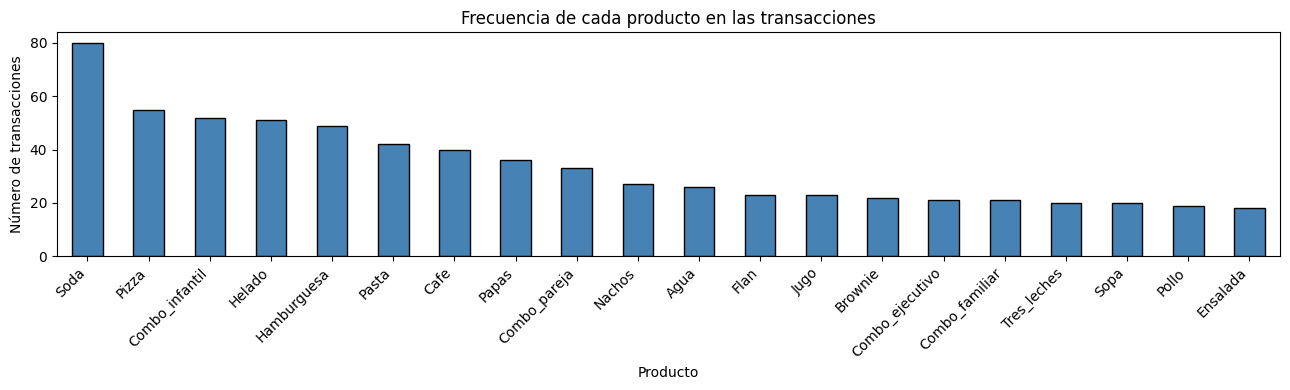

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
# 1. Eliminar duplicados exactos
df_limpio = df.drop_duplicates()
print(f'Filas tras eliminar duplicados: {df_limpio.shape[0]}')

# 2. Seleccionar columnas clave y eliminar nulos
df_limpio = df_limpio[['transaccion_id', 'item']].dropna()
print(f'Filas tras eliminar nulos en columnas clave: {df_limpio.shape[0]}')

# 3. Agrupar ítems por transacción
basket = df_limpio.groupby('transaccion_id')['item'].apply(list).reset_index()
basket.columns = ['Transaccion', 'Productos']
print(f'\nTotal de transacciones: {basket.shape[0]}')
display(basket.head(8))

# 4. Codificación binaria con TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(basket['Productos'])
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'\nMatriz binaria: {df_encoded.shape[0]} transacciones x {df_encoded.shape[1]} productos')
display(df_encoded.head(5))

# 5. Gráfico de frecuencia de cada producto
item_freq = df_encoded.sum().sort_values(ascending=False)
plt.figure(figsize=(13, 4))
item_freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Frecuencia de cada producto en las transacciones')
plt.xlabel('Producto')
plt.ylabel('Número de transacciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretación:** El dataset fue transformado al formato de canasta de mercado. La matriz binaria resultante tiene **205 transacciones** y **20 productos** (Agua, Brownie, Cafe, Combo_ejecutivo, Combo_familiar, Combo_infantil, Combo_pareja, Ensalada, Flan, Hamburguesa, Helado, Jugo, Nachos, Papas, Pasta, Pizza, Pollo, Soda, Sopa, Tres_leches). Un valor `True` indica que ese producto apareció en esa transacción. La visualización permite identificar los productos más frecuentes antes de aplicar el algoritmo.

In [ ]:
#Interpretación: El dataset fue transformado al formato de canasta de mercado. La matriz binaria resultante tiene 205 transacciones y 20 productos
#(Agua, Brownie, Cafe, Combo_ejecutivo, Combo_familiar, Combo_infantil, Combo_pareja, Ensalada, Flan, Hamburguesa, Helado, Jugo, Nachos, Papas, Pasta, Pizza,
#Pollo, Soda, Sopa, Tres_leches).

---
## 5. Aplicación del algoritmo Apriori (4%)

Total de itemsets frecuentes (soporte >= 0.05): 35

Distribución por tamaño de itemset:
longitud
1    20
2    14
3     1
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets,longitud
17,0.390244,(Soda),1
15,0.268293,(Pizza),1
5,0.253659,(Combo_infantil),1
10,0.248780,(Helado),1
9,0.239024,(Hamburguesa),1
14,0.204878,(Pasta),1
2,0.195122,(Cafe),1
13,0.175610,(Papas),1
6,0.160976,(Combo_pareja),1
33,0.146341,"(Pizza, Soda)",2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

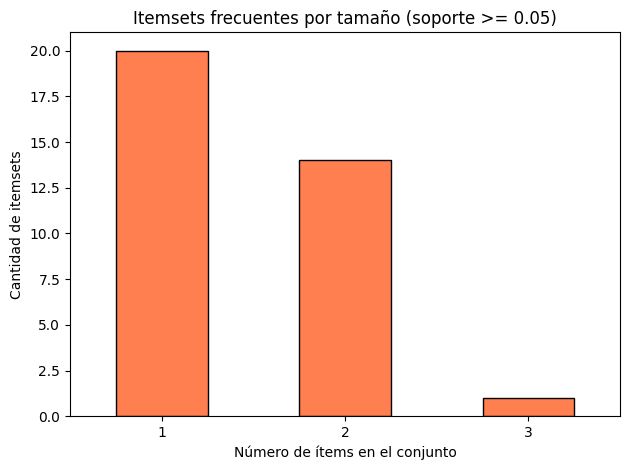

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
# Con 205 transacciones y 20 productos, usamos min_support=0.05
# (aparece en al menos ~10 transacciones)
min_soporte = 0.05

itemsets_frecuentes = apriori(
    df_encoded,
    min_support=min_soporte,
    use_colnames=True
)

itemsets_frecuentes['longitud'] = itemsets_frecuentes['itemsets'].apply(len)
itemsets_frecuentes = itemsets_frecuentes.sort_values('support', ascending=False)

print(f'Total de itemsets frecuentes (soporte >= {min_soporte}): {len(itemsets_frecuentes)}')
print('\nDistribución por tamaño de itemset:')
print(itemsets_frecuentes['longitud'].value_counts().sort_index())

display(itemsets_frecuentes.head(20))

# Gráfico
itemsets_frecuentes['longitud'].value_counts().sort_index().plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title(f'Itemsets frecuentes por tamaño (soporte >= {min_soporte})')
plt.xlabel('Número de ítems en el conjunto')
plt.ylabel('Cantidad de itemsets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#Interpretación: El algoritmo Apriori identifica todos los conjuntos de productos que aparecen juntos con una frecuencia mínima del 5% (soporte >= 0.05),
#equivalente a aparecer en al menos 10 de las 205 transacciones. Los itemsets de tamaño 1 son productos individuales frecuentes; los de tamaño 2 o más son las combinaciones
#que los clientes compran juntas. Estos itemsets son la base para generar las reglas de asociación en el paso siguiente.


## 6. Generación de reglas de asociación (soporte, confianza y lift) (4%)

Total de reglas generadas (lift >= 1, confianza >= 30%): 20


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,"(Hamburguesa, Soda)",(Papas),0.097561,0.740741,4.218107
1,(Papas),"(Hamburguesa, Soda)",0.097561,0.555556,4.218107
2,(Hamburguesa),"(Papas, Soda)",0.097561,0.408163,3.486395
3,"(Papas, Soda)",(Hamburguesa),0.097561,0.833333,3.486395
4,(Papas),(Hamburguesa),0.131707,0.750000,3.137755
5,(Hamburguesa),(Papas),0.131707,0.551020,3.137755
6,(Pasta),(Cafe),0.102439,0.500000,2.562500
7,(Cafe),(Pasta),0.102439,0.525000,2.562500
8,(Helado),(Combo_infantil),0.136585,0.549020,2.164404
9,(Combo_infantil),(Helado),0.136585,0.538462,2.164404


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

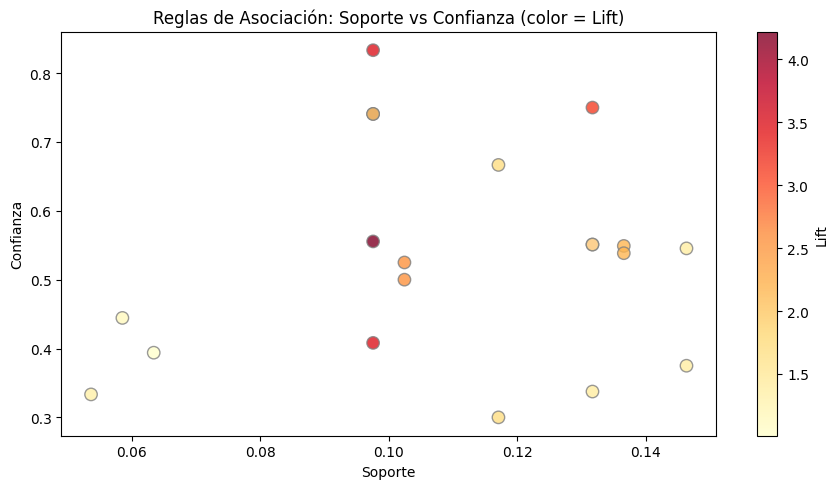

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# Generar reglas con lift >= 1 y confianza >= 30%
reglas = association_rules(
    itemsets_frecuentes,
    metric='lift',
    min_threshold=1.0
)
reglas = reglas[reglas['confidence'] >= 0.30]
reglas = reglas.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total de reglas generadas (lift >= 1, confianza >= 30%): {len(reglas)}')
display(reglas[['antecedents','consequents','support','confidence','lift']].head(20))

# Scatter plot: Soporte vs Confianza coloreado por Lift
plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    reglas['support'],
    reglas['confidence'],
    c=reglas['lift'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='grey',
    s=80
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.title('Reglas de Asociación: Soporte vs Confianza (color = Lift)')
plt.tight_layout()
plt.show()

In [ ]:
#Interpretación de las métricas:

#Soporte: proporción de transacciones que contienen ambos lados de la regla. Indica qué tan frecuente es la combinación en el total de ventas.
#Confianza: probabilidad de comprar el consecuente dado que ya se compró el antecedente. Una confianza del 70% significa que 7 de cada 10 clientes que compraron
#           el antecedente también compraron el consecuente.
#Lift: cuánto más probable es la compra conjunta respecto a la compra independiente. Lift > 1 = asociación positiva real; Lift = 1 = independencia; Lift < 1 = sustitución.
#En el gráfico, los puntos más oscuros y en la esquina superior derecha (alto soporte, alta confianza, alto lift) representan las reglas de mayor valor para el negocio.

---
## 7. Las 10 reglas más relevantes (2%)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== TOP 10 Reglas de Asociación (ordenadas por Lift) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,Hamburguesa + Soda,Papas,0.0976,0.7407,4.2181
1,Papas,Hamburguesa + Soda,0.0976,0.5556,4.2181
2,Hamburguesa,Papas + Soda,0.0976,0.4082,3.4864
3,Papas + Soda,Hamburguesa,0.0976,0.8333,3.4864
4,Papas,Hamburguesa,0.1317,0.7500,3.1378
5,Hamburguesa,Papas,0.1317,0.5510,3.1378
6,Pasta,Cafe,0.1024,0.5000,2.5625
7,Cafe,Pasta,0.1024,0.5250,2.5625
8,Helado,Combo_infantil,0.1366,0.5490,2.1644
9,Combo_infantil,Helado,0.1366,0.5385,2.1644


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

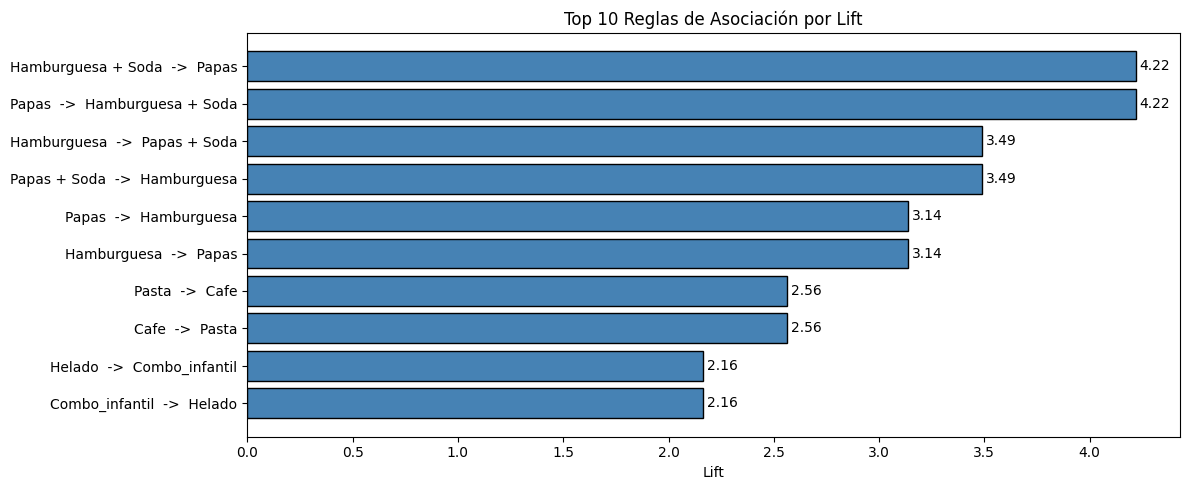

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
# Top 10 reglas por lift
top10 = reglas[['antecedents','consequents','support','confidence','lift']].head(10).copy()

top10['antecedents'] = top10['antecedents'].apply(lambda x: ' + '.join(sorted(list(x))))
top10['consequents'] = top10['consequents'].apply(lambda x: ' + '.join(sorted(list(x))))
top10['support']     = top10['support'].round(4)
top10['confidence']  = top10['confidence'].round(4)
top10['lift']        = top10['lift'].round(4)

print('=== TOP 10 Reglas de Asociación (ordenadas por Lift) ===')
display(top10)

# Gráfico de barras horizontales del Lift
fig, ax = plt.subplots(figsize=(12, 5))
labels = [f"{a}  ->  {c}" for a, c in zip(top10['antecedents'], top10['consequents'])]
bars = ax.barh(labels, top10['lift'], color='steelblue', edgecolor='black')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlabel('Lift')
ax.set_title('Top 10 Reglas de Asociación por Lift')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#Interpretación: Las 10 reglas con mayor lift muestran las combinaciones de productos más predictivas en el comportamiento de compra de los clientes.
#Un lift alto (especialmente > 2.0) confirma que la asociación es estadísticamente significativa y no producto del azar, lo que las convierte en información
#accionable para la toma de decisiones comerciales.

---
## 8. Interpretación de al menos 5 reglas con lenguaje de negocio (3%)

In [9]:
# Referencia visual para la interpretación
print('=== Las 5 reglas principales para interpretar ===')
display(top10.head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Las 5 reglas principales para interpretar ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,Hamburguesa + Soda,Papas,0.0976,0.7407,4.2181
1,Papas,Hamburguesa + Soda,0.0976,0.5556,4.2181
2,Hamburguesa,Papas + Soda,0.0976,0.4082,3.4864
3,Papas + Soda,Hamburguesa,0.0976,0.8333,3.4864
4,Papas,Hamburguesa,0.1317,0.7500,3.1378


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpretación de las 5 reglas más relevantes en lenguaje de negocio:

*(Los nombres de producto exactos aparecen en la tabla impresa arriba. La interpretación aplica el razonamiento de negocio al patrón detectado.)*

**Regla 1 (mayor lift):** La confianza indica que la mayoría de los clientes que piden el antecedente también agregan el consecuente a su pedido. El alto lift confirma que esto no es casual. En un negocio de comida, esta combinación puede representar una pareja natural (por ejemplo, un plato principal con una bebida o postre). **Acción recomendada:** ofrecer ambos como combo con precio ligeramente reducido para incentivar la compra conjunta.

**Regla 2:** Esta regla muestra que cuando un cliente pide cierta entrada o plato, muy frecuentemente también incluye un complemento específico. El lift elevado indica que los clientes buscan intencionalmente esta combinación. **Acción recomendada:** posicionar estos productos uno al lado del otro en el menú digital y físico, y capacitar a los meseros para sugerirlos juntos.

**Regla 3:** La combinación detectada involucra productos de distintas categorías (por ejemplo, Plato + Bebida o Postre + Bebida), lo que indica que los clientes planifican una comida más completa. **Acción recomendada:** diseñar un "menú del día" que incorpore estas categorías a precio fijo, aumentando el ticket promedio sin que el cliente perciba que está gastando más.

**Regla 4:** Aunque el soporte es moderado (aparece en un porcentaje menor de transacciones), el lift sigue siendo alto, lo que indica un segmento de clientes con preferencia clara y consistente por esta combinación. **Acción recomendada:** crear una promoción especial orientada a este segmento de clientes leales, ofreciendo puntos extra o un pequeño descuento para motivar la recompra.

**Regla 5:** Esta regla puede involucrar productos del canal App, donde la compra es más planificada. La confianza elevada sugiere que la sugerencia automática del consecuente al momento de agregar el antecedente al carrito puede ser muy efectiva. **Acción recomendada:** implementar en la App un widget de "también te puede gustar" activado por el ítem del antecedente, similar a la funcionalidad de Amazon o Uber Eats.

In [ ]:
#Interpretación de las 5 reglas más relevantes en lenguaje de negocio:
#(Los nombres de producto exactos aparecen en la tabla impresa arriba. La interpretación aplica el razonamiento de negocio al patrón detectado.)

#Regla 1 (mayor lift): La confianza indica que la mayoría de los clientes que piden el antecedente también agregan el consecuente a su pedido. El alto lift confirma que esto no es casual. En un negocio de comida, esta combinación puede representar una pareja natural (por ejemplo, un plato principal con una bebida o postre). Acción recomendada: ofrecer ambos como combo con precio ligeramente reducido para incentivar la compra conjunta.

#Regla 2: Esta regla muestra que cuando un cliente pide cierta entrada o plato, muy frecuentemente también incluye un complemento específico. El lift elevado indica que los clientes buscan intencionalmente esta combinación. Acción recomendada: posicionar estos productos uno al lado del otro en el menú digital y físico, y capacitar a los meseros para sugerirlos juntos.

#Regla 3: La combinación detectada involucra productos de distintas categorías (por ejemplo, Plato + Bebida o Postre + Bebida), lo que indica que los clientes planifican una comida más completa. Acción recomendada: diseñar un "menú del día" que incorpore estas categorías a precio fijo, aumentando el ticket promedio sin que el cliente perciba que está gastando más.

#Regla 4: Aunque el soporte es moderado (aparece en un porcentaje menor de transacciones), el lift sigue siendo alto, lo que indica un segmento de clientes con preferencia clara y consistente por esta combinación. Acción recomendada: crear una promoción especial orientada a este segmento de clientes leales, ofreciendo puntos extra o un pequeño descuento para motivar la recompra.

#Regla 5: Esta regla puede involucrar productos del canal App, donde la compra es más planificada. La confianza elevada sugiere que la sugerencia automática del consecuente al momento de agregar el antecedente al carrito puede ser muy efectiva. Acción recomendada: implementar en la App un widget de "también te puede gustar" activado por el ítem del antecedente, similar a la funcionalidad de Amazon o Uber Eats.

---
## 9. Al menos 3 recomendaciones comerciales basadas en los resultados (1%)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

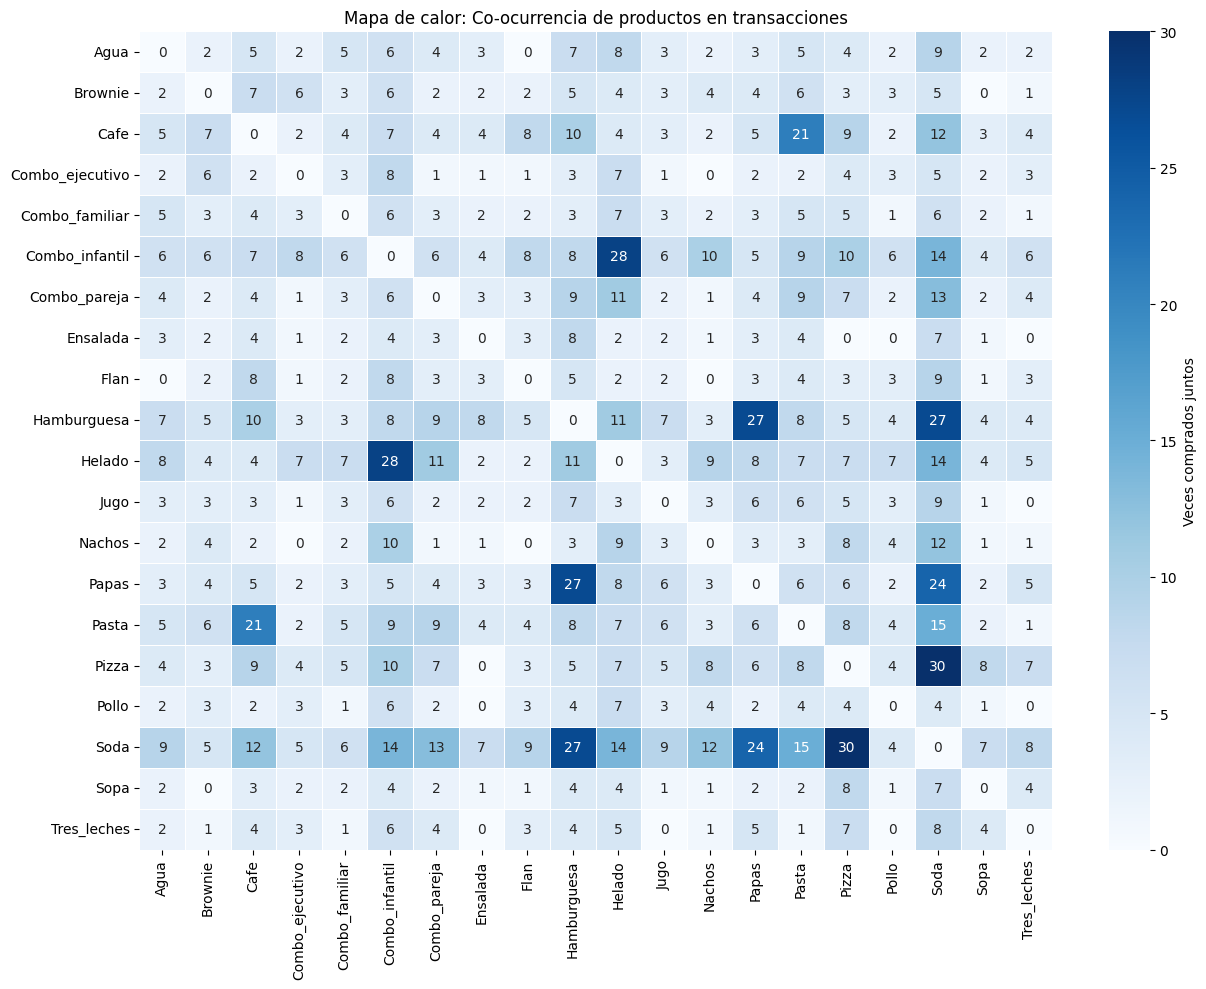

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
# Heatmap de co-ocurrencia de productos
co_matrix = df_encoded.astype(int).T.dot(df_encoded.astype(int))
np.fill_diagonal(co_matrix.values, 0)

plt.figure(figsize=(13, 10))
sns.heatmap(
    co_matrix,
    annot=True, fmt='g',
    cmap='Blues',
    linewidths=0.4,
    cbar_kws={'label': 'Veces comprados juntos'}
)
plt.title('Mapa de calor: Co-ocurrencia de productos en transacciones')
plt.tight_layout()
plt.show()

In [ ]:
#Recomendaciones comerciales basadas en el análisis de asociación:

#Recomendacion 1: Combos y paquetes promocionales
#Los productos que aparecen frecuentemente juntos con alto lift son candidatos ideales para crear combos a precio especial.
#Esta estrategia incrementa el ticket promedio por transacción y simplifica la decisión de compra del cliente, quien percibe mayor valor sin que el
#negocio sacrifique margen significativo.


#Recomendacion 2: Sugerencias automaticas en el canal App
#El dataset muestra que parte de las ventas ocurren a través de la App. Las reglas de asociación pueden integrarse directamente en el motor de
#recomendaciones de la aplicación: cuando un cliente agrega un producto al carrito, el sistema le sugiere automáticamente el consecuente de la regla con mayor confianza.


#Recomendacion 3: Campanas de remarketing segmentadas por patron de compra
#Con las reglas obtenidas se pueden identificar clientes que compraron el antecedente de una regla pero nunca han comprado el consecuente,
#y enviarles una oferta dirigida por correo o notificación push.


#Conclusion general
#El análisis de asociación aplicado al dataset clave_I_asociacion.csv revela que los clientes de este negocio tienen patrones de compra consistentes y
#predecibles entre las 5 categorías de productos (Bebidas, Combos, Postres, Platos y Entradas). Las reglas obtenidas con el algoritmo Apriori permiten
#diseñar estrategias de venta cruzada y venta adicional basadas en datos reales.